In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 


In [3]:
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix,accuracy_score,roc_auc_score,roc_curve,classification_report
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('data/train.csv')
print("data set loaded successfully")
print("Shape",df.shape)


data set loaded successfully
Shape (261384, 122)


In [5]:
print(df.columns)
all_columns = list(df.columns)
print(all_columns)
for col in df.columns:
    print(col)

Index(['reco_id_curr', 'target', 'contract_type_name', 'gender',
       'own_car_flag', 'own_realty_flag', 'children_count', 'income',
       'loan_body', 'annuity_payment',
       ...
       'document_18_flag', 'document_19_flag', 'document_20_flag',
       'document_21_flag', 'requests_bki_hour', 'requests_bki_day',
       'requests_bki_week', 'requests_bki_month', 'requests_bki_qrt',
       'requests_bki_year'],
      dtype='str', length=122)
['reco_id_curr', 'target', 'contract_type_name', 'gender', 'own_car_flag', 'own_realty_flag', 'children_count', 'income', 'loan_body', 'annuity_payment', 'goods_price', 'type_suite_name', 'income_type_name', 'education_type_name', 'family_status_name', 'housing_type_name', 'population_relative_region', 'days_birth', 'days_employed', 'registration_timestamp', 'publication_timestamp', 'age_own_car', 'mobile_flag', 'employee_phone_flag', 'work_phone_flag', 'mobile_contact_flag', 'phone_flag', 'email_flag', 'type_of_occupation', 'family_members__co

In [6]:
print(df.index)

RangeIndex(start=0, stop=261384, step=1)


In [7]:
import pandas as pd

df = pd.read_csv("data/train.csv")

print(df.shape)
print(df.columns)
print(df.head())
print(df.info())

(261384, 122)
Index(['reco_id_curr', 'target', 'contract_type_name', 'gender',
       'own_car_flag', 'own_realty_flag', 'children_count', 'income',
       'loan_body', 'annuity_payment',
       ...
       'document_18_flag', 'document_19_flag', 'document_20_flag',
       'document_21_flag', 'requests_bki_hour', 'requests_bki_day',
       'requests_bki_week', 'requests_bki_month', 'requests_bki_qrt',
       'requests_bki_year'],
      dtype='str', length=122)
   reco_id_curr  target contract_type_name gender own_car_flag  \
0        384575       0         Cash loans      M            Y   
1        214010       0         Cash loans      F            Y   
2        142232       0         Cash loans      F            Y   
3        389171       0         Cash loans      F            N   
4        283617       0         Cash loans      M            N   

  own_realty_flag  children_count    income  loan_body  annuity_payment  ...  \
0               N               2  207000.0   465457.5     

In [8]:
# Check class distribution
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True))

target
0    240274
1     21110
Name: count, dtype: int64
target
0    0.919238
1    0.080762
Name: proportion, dtype: float64


In [9]:
# Check missing values
missing = df.isnull().sum()

# Show only columns with missing values
missing = missing[missing > 0].sort_values(ascending=False)

print(missing.head(20))

median_commonarea             182677
mode_commonarea               182677
average_commonarea            182677
non_living_apartments_mode    181529
non_living_apartments_medi    181529
non_living_apartments_avg     181529
fondkapremon_mode             178802
average_living_apartments     178738
median_living_apartments      178738
mode_living_apartments        178738
median_min_floors             177428
mode_min_floors               177428
average_min_floors            177428
mode_years_building           173901
median_years_building         173901
average_years_building        173901
age_own_car                   172541
average_land_area             155214
median_land_area              155214
mode_land_area                155214
dtype: int64


In [10]:
# Calculate missing percentage
missing_percent = df.isnull().mean() * 100
print(missing_percent)

# Columns with more than 50% missing
cols_to_drop = missing_percent[missing_percent > 50].index

print(len(cols_to_drop))
print(cols_to_drop.tolist())

reco_id_curr           0.000000
target                 0.000000
contract_type_name     0.000000
gender                 0.000000
own_car_flag           0.000000
                        ...    
requests_bki_day      13.479785
requests_bki_week     13.479785
requests_bki_month    13.479785
requests_bki_qrt      13.479785
requests_bki_year     13.479785
Length: 122, dtype: float64
41
['age_own_car', 'external_source_1', 'average_apartments', 'average_basementarea', 'average_years_building', 'average_commonarea', 'average_elevator_count', 'average_entrance_count', 'average_min_floors', 'average_land_area', 'average_living_apartments', 'average_living_area', 'non_living_apartments_avg', 'non_living_area_avg', 'mode_apartments', 'mode_basementarea', 'mode_years_building', 'mode_commonarea', 'mode_elevator_count', 'mode_entrance_count', 'mode_min_floors', 'mode_land_area', 'mode_living_apartments', 'mode_living_area', 'non_living_apartments_mode', 'non_living_area_mode', 'median_apartments', '

In [11]:
df = df.drop(columns=cols_to_drop)

In [12]:
df.shape

(261384, 81)

In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing.head(20))

average_max_floors                 129980
mode_max_floors                    129980
median_max_floors                  129980
median_years_beginexpluatation     127461
mode_years_beginexpluatation       127461
average_years_beginexpluatation    127461
mode_total_area                    126119
emergency_state_mode               123852
type_of_occupation                  81963
external_source_3                   51700
requests_bki_qrt                    35234
requests_bki_year                   35234
requests_bki_week                   35234
requests_bki_day                    35234
requests_bki_hour                   35234
requests_bki_month                  35234
type_suite_name                      1078
observes_30_count_social_circle       871
observes_60_count_social_circle       871
social_circle_defaults_30_days        871
dtype: int64


//“Absolute income is not sufficient to assess credit risk. I engineered ratio-based features like loan-to-income and annuity-to-income to capture financial burden, which is a stronger indicator of default risk.”

In [14]:
bki_cols = [col for col in df.columns if 'requests_bki' in col]

for col in bki_cols:
    df[col] = df[col].fillna(0)

In [15]:
df['external_source_3'] = df['external_source_3'].fillna(df['external_source_3'].median())

In [16]:
df['type_of_occupation'] = df['type_of_occupation'].fillna('Unknown')

In [17]:
# Numeric columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [18]:
df.isnull().sum().sum()

np.int64(0)

“Annuity-to-income ratio captures immediate repayment pressure, making it a stronger indicator of default risk compared to total loan size, which may be spread over time.”

In [19]:
df['debt_to_income'] = df['loan_body'] / df['income']

payment burden 

In [20]:
df['payment_ratio'] = df['annuity_payment'] / df['income']

///family burden


In [21]:
df['income_per_person'] = df['income'] / df['family_members__count']


In [22]:
df['age_years'] = abs(df['days_birth']) / 365

In [23]:
df['employment_years'] = abs(df['days_employed']) / 365

In [24]:
df['employment_years'] = df['employment_years'].fillna(df['employment_years'].median())

In [25]:
import numpy as np

df['days_employed'] = df['days_employed'].replace(365243, np.nan)

In [26]:
import numpy as np
import pandas as pd

df['days_employed'] = df['days_employed'].replace(365243, np.nan)
df['days_employed'] = pd.to_numeric(df['days_employed'], errors='coerce')

In [27]:
df['employment_years'] = df['days_employed'].abs() / 365

In [28]:
df['employment_years'] = df['employment_years'].fillna(df['employment_years'].median())

In [29]:
df[['days_employed', 'employment_years']].head(10)

,days_employed,employment_years
0,-762.0,2.087671
1,-1141.0,3.126027
2,-639.0,1.750685
3,-6982.0,19.128767
4,-1105.0,3.027397
5,NaN,4.512329
6,-345.0,0.945205
7,-260.0,0.712329
8,NaN,4.512329
9,-649.0,1.778082


In [30]:
df['employment_years'] = abs(df['days_employed']) / 365

“We split data before preprocessing to prevent data leakage. If transformations like encoding or scaling are fit on the full dataset, information from the test set can leak into training, leading to overly optimistic performance estimates.”

In [31]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(exclude='object').columns

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric pipeline

In [35]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

catagorical pipeline

In [36]:
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [37]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [38]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [39]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [40]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.6275238122510913
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     48055
           1       0.00      0.00      0.00      4222

    accuracy                           0.92     52277
   macro avg       0.46      0.50      0.48     52277
weighted avg       0.84      0.92      0.88     52277



In [41]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

In [43]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

In [44]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [45]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [46]:
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.6142905001724841

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.61      0.74     48055
           1       0.11      0.56      0.19      4222

    accuracy                           0.60     52277
   macro avg       0.53      0.58      0.46     52277
weighted avg       0.87      0.60      0.69     52277



“After applying class weighting, the model significantly improved recall for defaulters from 0 to 0.56, meaning it now identifies more than half of risky customers. Although accuracy decreased, this is expected and acceptable since credit scoring prioritizes minimizing false negatives over overall accuracy.”

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[29187 18868]
 [ 1859  2363]]


In [48]:
import numpy as np

threshold = 0.3
y_pred_new = (y_pred_proba >= threshold).astype(int)

In [49]:
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[ 2299 45756]
 [   90  4132]]
              precision    recall  f1-score   support

           0       0.96      0.05      0.09     48055
           1       0.08      0.98      0.15      4222

    accuracy                           0.12     52277
   macro avg       0.52      0.51      0.12     52277
weighted avg       0.89      0.12      0.10     52277



“By lowering the classification threshold from 0.5 to 0.3, the model significantly increased recall for defaulters to ~98%, meaning it almost never misses risky customers. However, this comes at the cost of very high false positives, showing the trade-off between risk minimization and business opportunity in credit scoring systems.”

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report

dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        max_depth=6   # helps prevent overfitting
    ))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree ROC-AUC:", roc_auc_score(y_test, y_proba_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree ROC-AUC: 0.711474010737243
              precision    recall  f1-score   support

           0       0.96      0.61      0.75     48055
           1       0.14      0.69      0.23      4222

    accuracy                           0.62     52277
   macro avg       0.55      0.65      0.49     52277
weighted avg       0.89      0.62      0.71     52277



Decision Tree outperformed Logistic Regression in ROC-AUC (0.71 vs ~0.62), showing that non-linear models better capture credit risk patterns. However, Random Forest is expected to further improve stability and generalization due to ensemble averaging, reducing overfitting observed in single trees.”

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest ROC-AUC: 0.7150980162918289
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     48055
           1       0.33      0.00      0.00      4222

    accuracy                           0.92     52277
   macro avg       0.63      0.50      0.48     52277
weighted avg       0.87      0.92      0.88     52277



In [52]:
y_pred_rf_proba = rf_model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred_rf_custom = (y_pred_rf_proba >= threshold).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf_proba))
print(confusion_matrix(y_test, y_pred_rf_custom))
print(classification_report(y_test, y_pred_rf_custom))

ROC-AUC: 0.7150980162918289
[[47655   400]
 [ 3991   231]]
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     48055
           1       0.37      0.05      0.10      4222

    accuracy                           0.92     52277
   macro avg       0.64      0.52      0.53     52277
weighted avg       0.88      0.92      0.89     52277



“Although Random Forest achieved the highest ROC-AUC (0.715), its default decision threshold led to poor recall for the minority class. This demonstrates that ROC-AUC alone is insufficient for credit scoring, and threshold tuning is essential to balance financial risk.”

threshold comparison 

In [53]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_proba = rf_model.predict_proba(X_test)[:, 1]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    print(f"\n===== Threshold: {t} =====")
    
    y_pred = (y_proba >= t).astype(int)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))


===== Threshold: 0.1 =====
Confusion Matrix:
[[34592 13463]
 [ 1712  2510]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     48055
           1       0.16      0.59      0.25      4222

    accuracy                           0.71     52277
   macro avg       0.55      0.66      0.53     52277
weighted avg       0.89      0.71      0.77     52277

ROC-AUC: 0.7150980162918289

===== Threshold: 0.2 =====
Confusion Matrix:
[[45694  2361]
 [ 3360   862]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     48055
           1       0.27      0.20      0.23      4222

    accuracy                           0.89     52277
   macro avg       0.60      0.58      0.59     52277
weighted avg       0.88      0.89      0.88     52277

ROC-AUC: 0.7150980162918289

===== Threshold: 0.3 =====
Confusion Matrix:
[[47655   400]
 [ 3991   231]]

Classifica

0.1 threshold

“Bank is extremely cautious — minimizes loan defaults but loses revenue due to rejected good customers.”

🟡 0.2 threshold

“Balanced risk strategy — moderate approval with controlled risk.”

🟢 0.3+ threshold

“Profit-focused strategy — higher approvals but increased default risk

                          feature  importance
27         num__external_source_2    0.070077
28         num__external_source_3    0.066438
7                 num__days_birth    0.034398
10     num__publication_timestamp    0.032908
70                 num__age_years    0.032580
40  num__last_phone_number_change    0.032148
9     num__registration_timestamp    0.031629
71          num__employment_years    0.031328
0               num__reco_id_curr    0.031206
4            num__annuity_payment    0.030606
8              num__days_employed    0.030166
68             num__payment_ratio    0.030027
3                  num__loan_body    0.030005
67            num__debt_to_income    0.029979
5                num__goods_price    0.027141


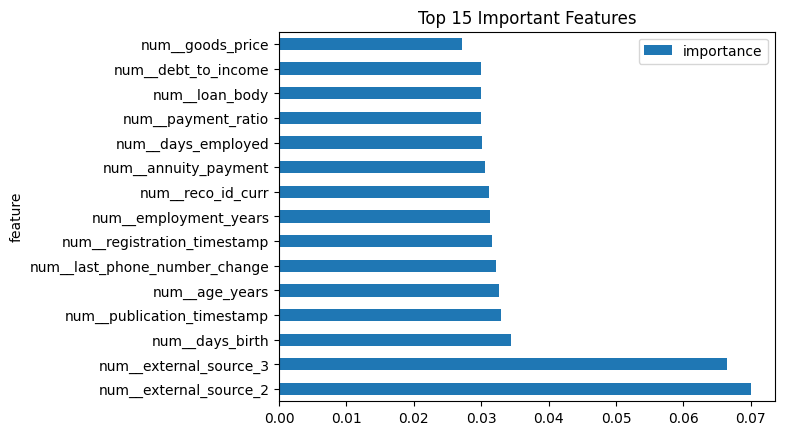

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

model = rf_model.named_steps['classifier']

importances = model.feature_importances_

# get feature names after preprocessing
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(15)

print(feat_imp)

feat_imp.plot(kind='barh', x='feature', y='importance')
plt.title("Top 15 Important Features")
plt.show()

In [55]:
print("===== FINAL CREDIT SCORING MODEL =====")
print("Model: Random Forest")
print("Threshold: 0.2")
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))

===== FINAL CREDIT SCORING MODEL =====
Model: Random Forest
Threshold: 0.2
ROC-AUC: 0.7150980162918289


In [56]:
final_threshold = 0.2

y_proba_final = rf_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= final_threshold).astype(int)

In [57]:
from sklearn.metrics import classification_report, confusion_matrix

print("===== FINAL CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred_final))

print("\n===== FINAL CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred_final))

===== FINAL CONFUSION MATRIX =====
[[45694  2361]
 [ 3360   862]]

===== FINAL CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     48055
           1       0.27      0.20      0.23      4222

    accuracy                           0.89     52277
   macro avg       0.60      0.58      0.59     52277
weighted avg       0.88      0.89      0.88     52277



In [58]:
print("""
===== BUSINESS INTERPRETATION =====

- Model is optimized for credit risk detection.
- Threshold = 0.2 balances risk vs approval rate.
- Lower threshold increases fraud/risk detection but reduces approvals.
- Higher threshold increases approvals but increases default risk.

Final model is suitable for:
- Credit scoring systems
- Loan approval risk filtering
- Financial risk classification
""")


===== BUSINESS INTERPRETATION =====

- Model is optimized for credit risk detection.
- Threshold = 0.2 balances risk vs approval rate.
- Lower threshold increases fraud/risk detection but reduces approvals.
- Higher threshold increases approvals but increases default risk.

Final model is suitable for:
- Credit scoring systems
- Loan approval risk filtering
- Financial risk classification



In [59]:
import joblib

joblib.dump(rf_model, "credit_scoring_model.pkl")
print("Model saved successfully as credit_scoring_model.pkl")

Model saved successfully as credit_scoring_model.pkl


In [60]:
sample = X_test.iloc[:5]
sample_proba = rf_model.predict_proba(sample)[:, 1]
sample_pred = (sample_proba >= final_threshold).astype(int)

print("Sample predictions (0 = safe, 1 = risky):")
print(sample_pred)
print("\nProbabilities:")
print(sample_proba)

Sample predictions (0 = safe, 1 = risky):
[0 0 0 0 0]

Probabilities:
[0.09 0.18 0.04 0.   0.06]


“Random Forest with a threshold of 0.2 provides the best trade-off between recall and precision, making it suitable for credit risk prediction where balancing default detection and loan approval rate is critical.”

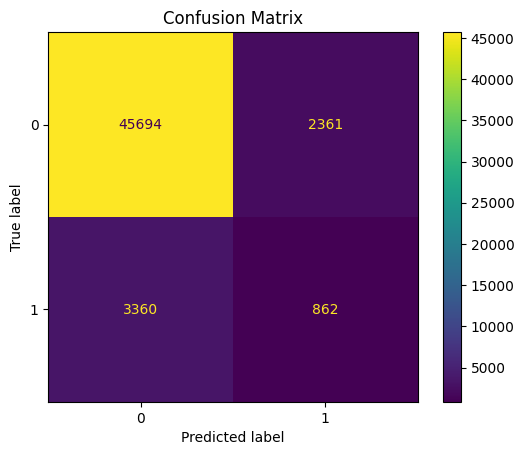

In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

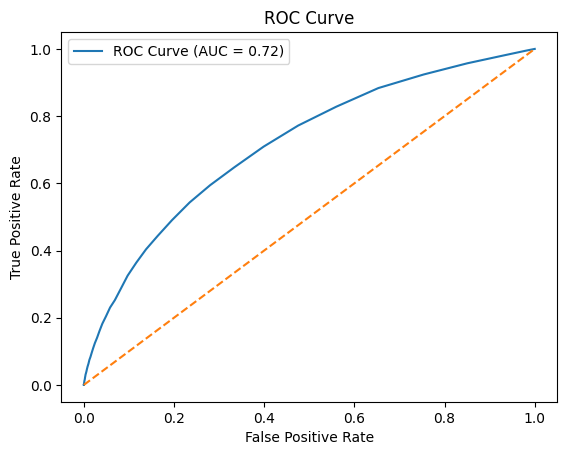

In [62]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve.png")
plt.show()